In [82]:
import numpy as np
import matplotlib.pyplot as plt

In [83]:
X = np.array([50, 60, 70, 80, 90])
y = np.array([150, 180, 210, 240, 270])

In [84]:
X_norm = (X - np.mean(X)) / np.std(X)

In [85]:
class LinearRegressionGD:

    def __init__(self, learning_rate=0.001, n_iters=100):
        """
        Initialize the Linear Regression model.

        Parameters
        ----------
        learning_rate : float
            Step size used by Gradient Descent to update the parameters.

        n_iters : int
            Number of iterations used to train the model.
        """

        self.lr = learning_rate
        self.n_iters = n_iters
        self.theta_0 = 0
        self.theta_1 = 0
        self.sse_history = []


    def fit(self, X, y):
        """
        Train the Linear Regression model using Gradient Descent.

        Parameters
        ----------
        X : numpy array
            Input feature values (house sizes).

        y : numpy array
            Target values (house prices).
        """

        n = len(X)

        for _ in range(self.n_iters):

            y_pred = self.theta_1 * X + self.theta_0

            error = y_pred - y

            sse = np.sum(error ** 2)
            self.sse_history.append(sse)

            d_theta1 = (2 / n) * np.sum(error * X)
            d_theta0 = (2 / n) * np.sum(error)

            self.theta_1 = self.theta_1 - self.lr * d_theta1
            self.theta_0 = self.theta_0 - self.lr * d_theta0


    def predict(self, X):
        """
        Predict target values using the learned regression model.
        """

        return self.theta_1 * X + self.theta_0


    def calculate_mse(self, X, y):
        """
        Calculate Mean Squared Error (MSE).
        """

        y_pred = self.predict(X)

        mse = np.mean((y_pred - y) ** 2)

        return mse


    def plot_training(self, X, y):
        """
        Visualize training progress and regression results.
        """

        plt.figure()
        plt.plot(self.sse_history)
        plt.title("SSE over iterations")
        plt.xlabel("Iteration")
        plt.ylabel("SSE")
        plt.show()

        y_pred = self.predict(X)

        plt.figure()
        plt.scatter(X, y, color="tomato", label="Data")
        plt.plot(X, y_pred, color="steelblue", label="Regression Line")
        plt.legend()
        plt.title("Regression Line")
        plt.show()

In [86]:
model = LinearRegressionGD(learning_rate=0.001, n_iters=100)

model.fit(X_norm,y)
print("theta_0:", round(model.theta_0,4))
print("theta_1:", round(model.theta_1,4))

theta_0: 38.101
theta_1: 7.6976


In [87]:
size = 70
size_norm = (size - np.mean(X)) / np.std(X)

prediction = model_norm.predict(size_norm)

print("Predicted price:", round(prediction, 2), "$")

Predicted price: 210.0 $


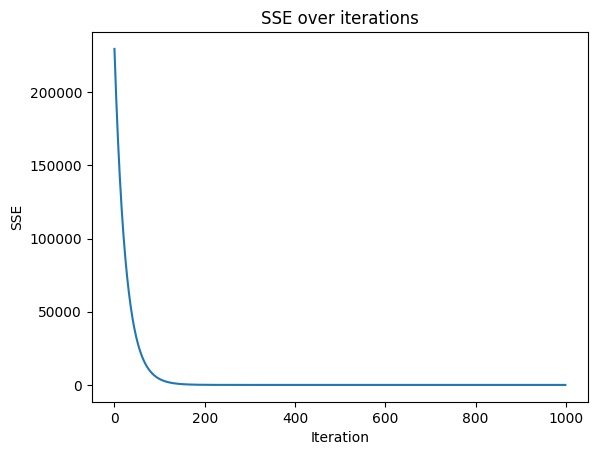

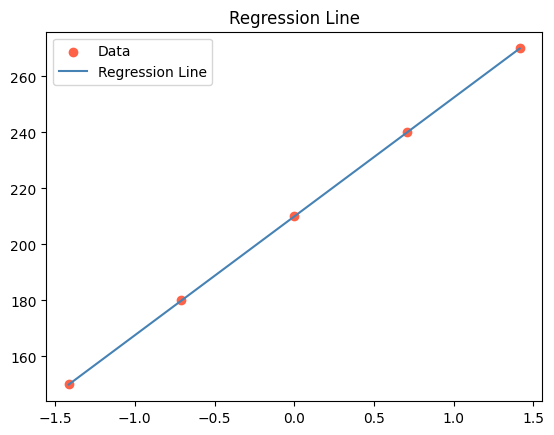

In [88]:
model_norm.plot_training(X_norm, y)

In [89]:
mse = model.calculate_mse(X, y)

print("MSE:", round(mse, 4))

MSE: 139051.0879


In [90]:
X_norm = (X - np.mean(X)) / np.std(X)

In [91]:
model_norm = LinearRegressionGD(learning_rate=0.01, n_iters=1000)

model_norm.fit(X_norm, y)
print("theta_0:", round(model_norm.theta_0,4))
print("theta_1:", round(model_norm.theta_1,4))
print("MSE:", round(model_norm.calculate_mse(X_norm, y),4))

theta_0: 210.0
theta_1: 42.4264
MSE: 0.0


In [ ]:
print("MSE before normalization:", model.calculate_mse(X, y))
print("MSE after normalization:", model_norm.calculate_mse(X_norm, y))

MSE before normalization: 139051.0879384367
MSE after normalization: 1.3000621891815375e-13


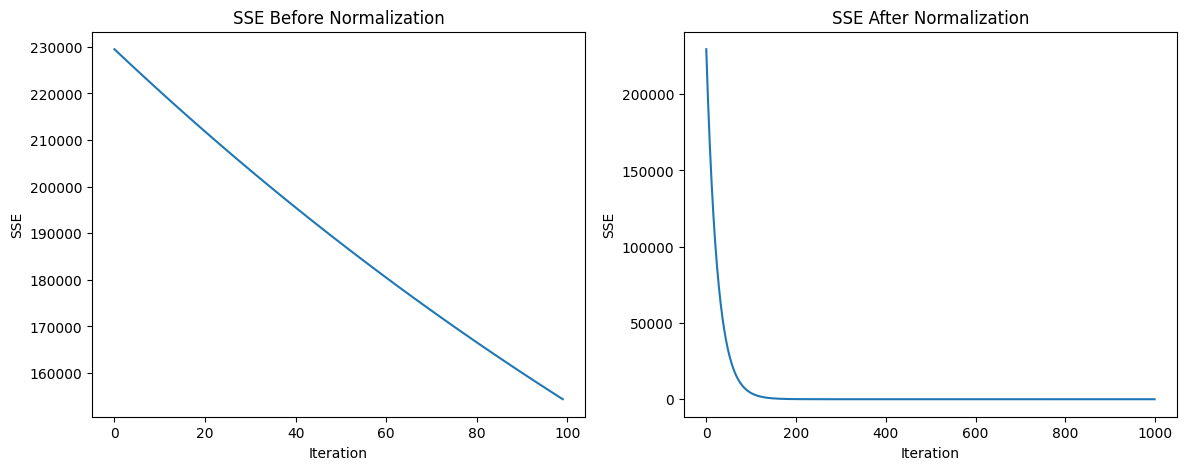

In [93]:
plt.figure(figsize=(14,5))

# Before normalization
plt.subplot(1,2,1)
plt.plot(model.sse_history)
plt.title("SSE Before Normalization")
plt.xlabel("Iteration")
plt.ylabel("SSE")

# After normalization
plt.subplot(1,2,2)
plt.plot(model_norm.sse_history)
plt.title("SSE After Normalization")
plt.xlabel("Iteration")
plt.ylabel("SSE")

plt.show()